## Weather Prediction Model

This model is used to predict Weather condition by using daily observation including Temperature, Wind and Precipitation, To determine the specific state of atmosphere if it's Rain, Sun, Snow, Fog and Drizzle.
Differenet Machine Learning Models such as Decision Tree, Random Free and Xgboosting were applied to discover pattern from data and make prediction, by involving the following steps
1. Objective of model
2. Data collection
3. Exploratory Data Analysis
4. Data preprocessing and Cleaning
5. Feature Engineering
6. Split Data
7. Build Model
8. Model Evaluation
9. Tune model and prediction
10. Save and Deployment

## Steps 1: Obejctive of the model
The goal is to predict whether the day will experience drizzle, rain, sunshine, snow, or fog, based on meteorological features such as precipitation, temperature, and wind.

## Steps 2: Data Collection
The dataset used is collected from Weather and meteorological station to measure atmospheric conditions such as temperature, wind, and humidity over period of time from 2012 to 2015 across east africa country such as Kenya, Tanzania and Uganda

About Dataset
This dataset contain six features which are 
1. Date -the period where atmospheric condition where recorderd, formatted as YYYY-MM-DD
2. Precipatation - form of water that fall from the sky and its measured in (mm)
3. temp_max - highest temperature recorded during the day, measured in °C
4. temp_min - lowest temperature recorded during the day, measured in °C
5. wind - avarge speed of wind during the day, measured in (km/s, m/s and mph)
6. weather - the short -specific state of atmosphere during the specific time (sun,rain,snow,drizzle and fog)


In [ ]:
# import necessary libraries for EDA and model building
import pandas as pd
import seaborn as sns
import numpy as np
from sqlalchemy import create_engine
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from xgboost import plot_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import joblib

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# import and load dataset from database
# database credentials
username = "postgres"
password = "1970"
host = "localhost"
port = "5432"
database = "climate"

# connection
engine = create_engine(
    f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
)

# Load data
df = pd.read_sql("SELECT * FROM Weather;", engine)

## Steps 3: Exploratory Data Analysis
This focus with understanding and examining weather datasets by applying various statistical method and visualize to identify the distribution, characteristics and relationshop between bariable to discover pattern and trending before modeling

In [3]:
# shape of the dataset
print("Shape of the dataset:", df.shape)

Shape of the dataset: (1461, 6)


In [4]:
# Display the first few rows of the DataFrame
df.head(10)

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain
5,2012-01-06,2.5,4.4,2.2,2.2,rain
6,2012-01-07,0.0,7.2,2.8,2.3,rain
7,2012-01-08,0.0,10.0,2.8,2.0,sun
8,2012-01-09,4.3,9.4,5.0,3.4,rain
9,2012-01-10,1.0,6.1,0.6,3.4,rain


In [5]:
# check information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1461 entries, 0 to 1460
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           1461 non-null   object 
 1   precipitation  1461 non-null   float64
 2   temp_max       1461 non-null   float64
 3   temp_min       1461 non-null   float64
 4   wind           1461 non-null   float64
 5   weather        1461 non-null   str    
dtypes: float64(4), object(1), str(1)
memory usage: 68.6+ KB


In [6]:
# check for null and missing values
if df.isnull().sum().sum() > 0:
    print("There are missing values in the dataset.")
else:
    print("There are no missing values in the dataset.")

There are no missing values in the dataset.


In [7]:
# check for duplicates
if df.duplicated().sum() > 0:
    print("There are duplicate rows in the dataset.")
else:    print("There are no duplicate rows in the dataset.")

There are no duplicate rows in the dataset.


In [8]:
# statistical summary
df.describe()

,precipitation,temp_max,temp_min,wind
count,1461.000000,1461.000000,1461.000000,1461.000000
mean,3.029432,16.439083,8.234771,3.241136
std,6.680194,7.349758,5.023004,1.437825
min,0.000000,-1.600000,-7.100000,0.400000
25%,0.000000,10.600000,4.400000,2.200000
50%,0.000000,15.600000,8.300000,3.000000
75%,2.800000,22.200000,12.200000,4.000000
max,55.900000,35.600000,18.300000,9.500000


#### Summury of statistics oberservation
Weather datasets contain 1461 record and six features, all record are unique,there is no duplicate and missing value 
The Mean of the Features show the highest variation between value since mostly mean are far away from the dataset

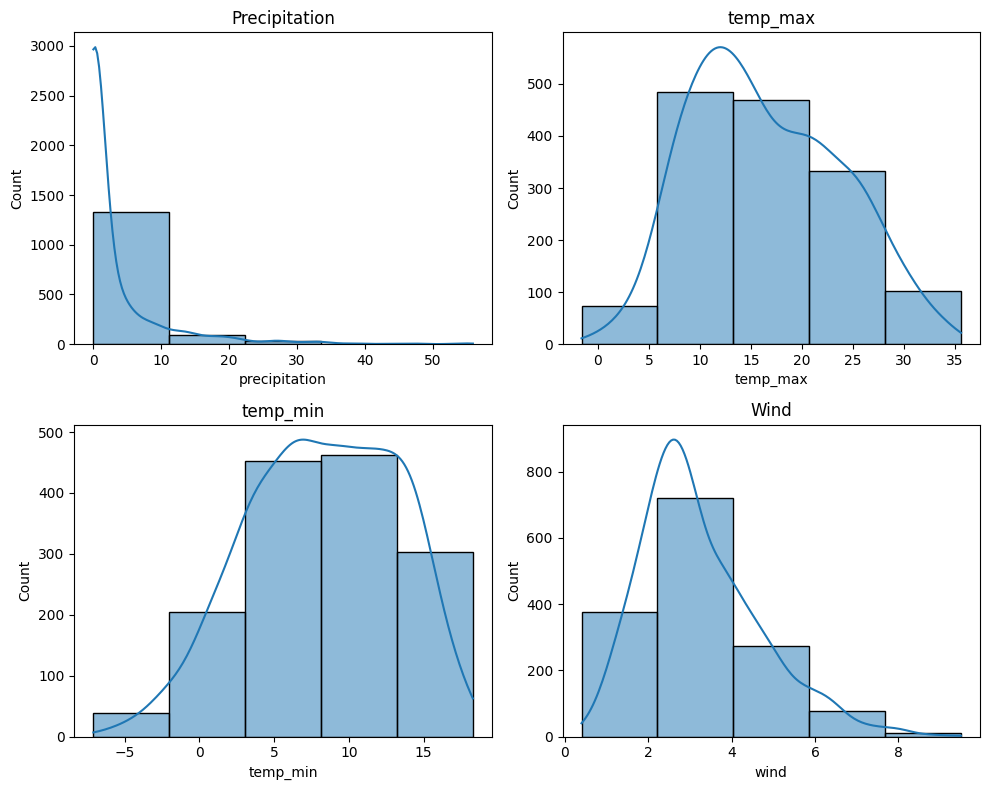

In [9]:
# Bivarite analysis
# Histogram of the features variables

# create 2 rows and 2 columns
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Flatten axes for easier indexing (optional but cleaner)
axes = axes.flatten()

# Histogram 1
sns.histplot(df["precipitation"], bins=5, kde=True, ax=axes[0])
axes[0].set_title("Precipitation")

# Histogram 2
sns.histplot(df["temp_max"], bins=5, kde=True, ax=axes[1])
axes[1].set_title("temp_max")

# Histogram 3
sns.histplot(df["temp_min"], bins=5, kde=True, ax=axes[2])
axes[2].set_title("temp_min")

# Histogram 4 (add another column from your dataset)
sns.histplot(df["wind"], bins=5, kde=True, ax=axes[3])
axes[3].set_title("Wind")

# adjust layout
plt.tight_layout()
plt.show()


### Summury for Distribution
The distribution of the features mostly is positive skewnes indicating that some of the areas experienced the much rainfall, hot condition and strong wind during the day.
But other place experiance more cold condition at the period of moring and night eg Nyari and Meru - Kenya, Kilimanjaro - tanzania, since most of negative value temperature are higher than others.

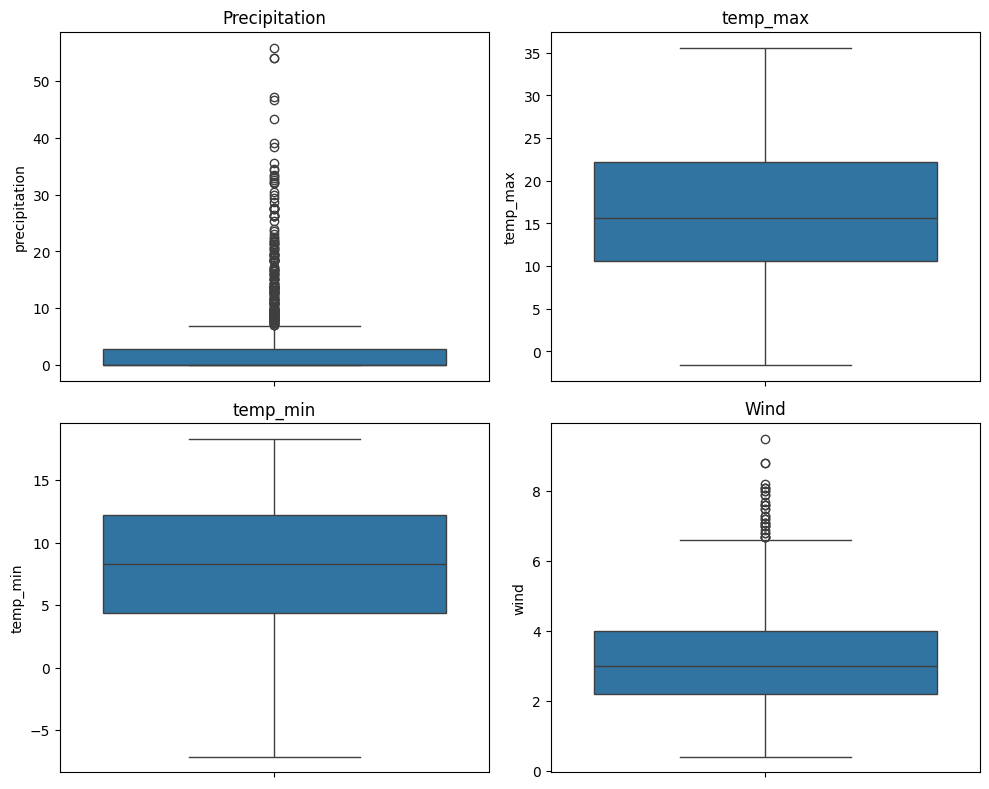

In [10]:
# Boxplot of the features variables

# create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

# Boxplot 1
sns.boxplot(y=df["precipitation"], ax=axes[0])
axes[0].set_title("Precipitation")

# Boxplot 2
sns.boxplot(y=df["temp_max"], ax=axes[1])
axes[1].set_title("temp_max")

# Boxplot 3
sns.boxplot(y=df["temp_min"], ax=axes[2])
axes[2].set_title("temp_min")

# Boxplot 4
sns.boxplot(y=df["wind"], ax=axes[3])  # replace with your column
axes[3].set_title("Wind")

plt.tight_layout()
plt.show()

### Summury for Box Plot
Precipitation and wind has extreme value means some of days had very high rainfall and strong wind compared to normal days, which lead to extreme weather event like floods,storm, Thunderstorm and pressure difference.

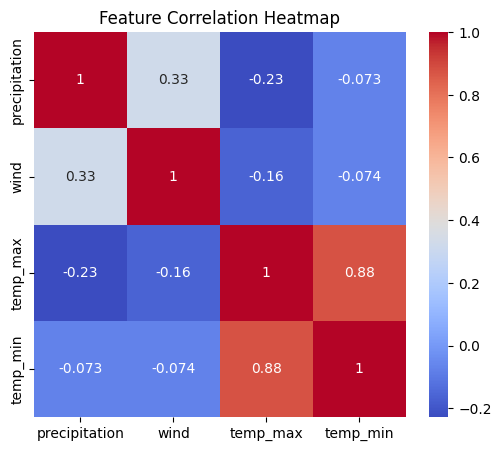

In [11]:

# correlation between numeric features only
corr = df[["precipitation", "wind", "temp_max", "temp_min"]].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

### Summury for Heat Map
Maximum tenp and min temp has very strong correlation indicating that hot condition during the day also tend to remain relative during the night and early morning, so there is multicolineality between temperature.

Also there is weak positive relationship between wind and rain fall indicating wind can indicating incoming rain

Wind and temperature have weak negative show that strong wind reduce amount of temperatue

Another relatioship are negative relatioship eg precipatation and temperature, show that when tempererature is high the atmosphere tend to be dry there is no moisture and when rain increase cloud block sunlight


## Steps 4: Data Preprocessing and Cleaning
In this step were are going to cleaning and transform data to determine it's quality and make it suitable for modeling by 

1. handling the missing value
2. handling outlier
3. remove duplicate

In [12]:
# handling Outliers by interquartile range (IQR) method
# check for outliers
df_clean = df.copy()

cols = ["wind", "precipitation"]

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # cap using loc
    df_clean.loc[df_clean[col] > upper, col] = upper
    df_clean.loc[df_clean[col] < lower, col] = lower

### Comments for Interquantile Range Method
Since the datastes is very small, its difficult to removing the extreme value becouse our model will be poor in prediction.
Also extreme value has the real meaning of weather condition in our datesets indicating diiferent weather experirnced during the day

So we apply capp method to limiting the extreme value and remain the datasets in the original shape, so that model can predict well

In [ ]:
# shape of the data before and after handling outliers
print("before outliers",len(df))
print("After outliers",len(df_clean))

before outliers 1461
After outliers 1461


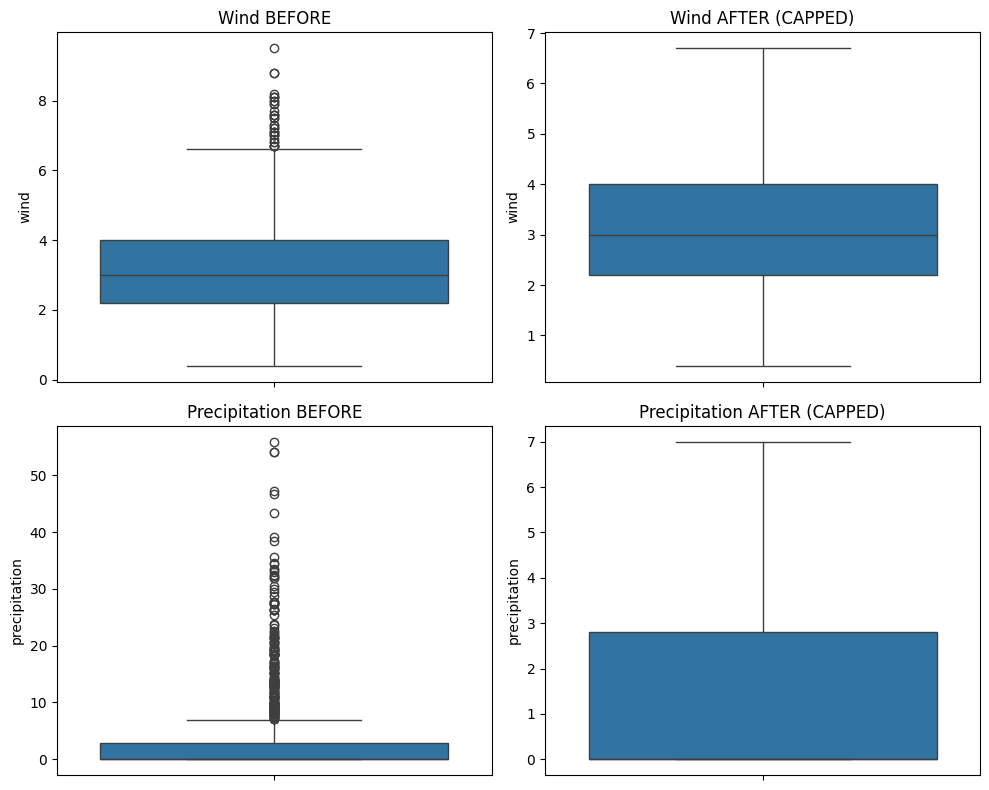

In [14]:
# Boxplot of the features variables after handling outliers
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# WIND
sns.boxplot(y=df["wind"], ax=axes[0, 0])
axes[0, 0].set_title("Wind BEFORE")

sns.boxplot(y=df_clean["wind"], ax=axes[0, 1])
axes[0, 1].set_title("Wind AFTER (CAPPED)")

# PRECIPITATION
sns.boxplot(y=df["precipitation"], ax=axes[1, 0])
axes[1, 0].set_title("Precipitation BEFORE")

sns.boxplot(y=df_clean["precipitation"], ax=axes[1, 1])
axes[1, 1].set_title("Precipitation AFTER (CAPPED)")

plt.tight_layout()
plt.show()

## Steps 5: feature Engineering
Adding new column of (month) to improve model performance, so that we can able to predict the weather condition by month

In [72]:
# Extracting the month name from the date column
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean["month"] = df_clean["date"].dt.month

In [ ]:
# see added column
df_clean.head()

,date,precipitation,temp_max,temp_min,wind,weather,month
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle,1
1,2012-01-02,7.0,10.6,2.8,4.5,rain,1
2,2012-01-03,0.8,11.7,7.2,2.3,rain,1
3,2012-01-04,7.0,12.2,5.6,4.7,rain,1
4,2012-01-05,1.3,8.9,2.8,6.1,rain,1


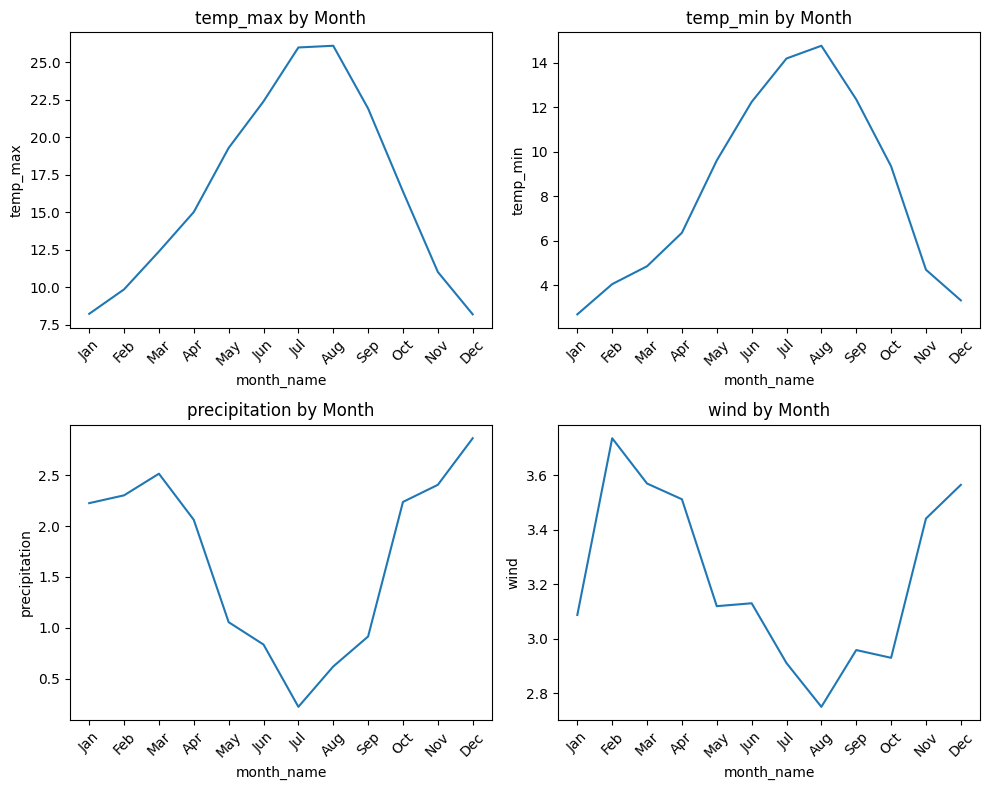

In [ ]:
#Bivariate analysis of the target variable
# group data by month and calculate mean of features
monthly_data = df_clean.groupby("month")[[
    "temp_max", "temp_min", "precipitation", "wind"
]].mean().reset_index()

# month names
month_map = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",
    5:"May",6:"Jun",7:"Jul",8:"Aug",
    9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

monthly_data["month_name"] = monthly_data["month"].map(month_map)

# plot line charts for each feature by month
features = ["temp_max", "temp_min", "precipitation", "wind"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.lineplot(x="month_name", y=col, data=monthly_data, ax=axes[i])
    axes[i].set_title(f"{col} by Month")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Summury for Time series plot
Based on our dataset, since max and min temperature are highly correlated, so temperature start to rise at the beggining of the year up to near end, and during mid of year there is hightest experience tempereture condition in some days.

Due to the Hightest tempereture at the mid of the year, tend to dencrease amount of rainfall and wind  especially in july and august, the strong wind and rainfall occur mostly at the beggining of the year (jan, feb , march and april) and at the end of the year (sept, oct, nov and dec)

## Steps 6: Split data
In datasets there are the five features (temp_max, temp_min, wind and precipitation) and one target (weather - which contain sun, rain, drizzle,snow and fog)
We are going to Split data, train our model to undestand pattern by 80% and test by 20% to see the performance of predict new data. 
Also drop target column from features then proceeding to the another steps

In [71]:
# unique values of the target variable
print(df_clean["weather"].unique())

<StringArray>
['drizzle', 'rain', 'sun', 'snow', 'fog']
Length: 5, dtype: str


In [74]:
# define target variable and features
target = "weather"
features = ["precipitation", "temp_max", "temp_min","wind", "month"]
X = df_clean[features]
y = df_clean[target]
print(f"features: {features}")
print(X)
print(f"target: {target}")
print(y)

features: ['precipitation', 'temp_max', 'temp_min', 'wind', 'month']
      precipitation  temp_max  temp_min  wind  month
0               0.0      12.8       5.0   4.7      1
1               7.0      10.6       2.8   4.5      1
2               0.8      11.7       7.2   2.3      1
3               7.0      12.2       5.6   4.7      1
4               1.3       8.9       2.8   6.1      1
...             ...       ...       ...   ...    ...
1456            7.0       4.4       1.7   2.9     12
1457            1.5       5.0       1.7   1.3     12
1458            0.0       7.2       0.6   2.6     12
1459            0.0       5.6      -1.0   3.4     12
1460            0.0       5.6      -2.1   3.5     12

[1461 rows x 5 columns]
target: weather
0       drizzle
1          rain
2          rain
3          rain
4          rain
         ...   
1456       rain
1457       rain
1458        fog
1459        sun
1460        sun
Name: weather, Length: 1461, dtype: str


In [ ]:
# drop date and target variable
X = df_clean.drop(["date", "weather"], axis=1)
y = df_clean["weather"]


# test train split by 20% for testing and 80% for training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 7: Building the Model

Since the dataset exhibits some multicollinearity among features, and the target variable is categorized into five classes, tree-based models such as Decision Tree and Random Forest are suitable choices. These models can effectively learn patterns from the data and perform classification to predict the target variable.

In [ ]:
# build Decision Tree model
d_model = DecisionTreeClassifier(random_state=42,max_depth=3)
d_model.fit(X_train, y_train)

# make predictions
y_pred = d_model.predict(X_test)

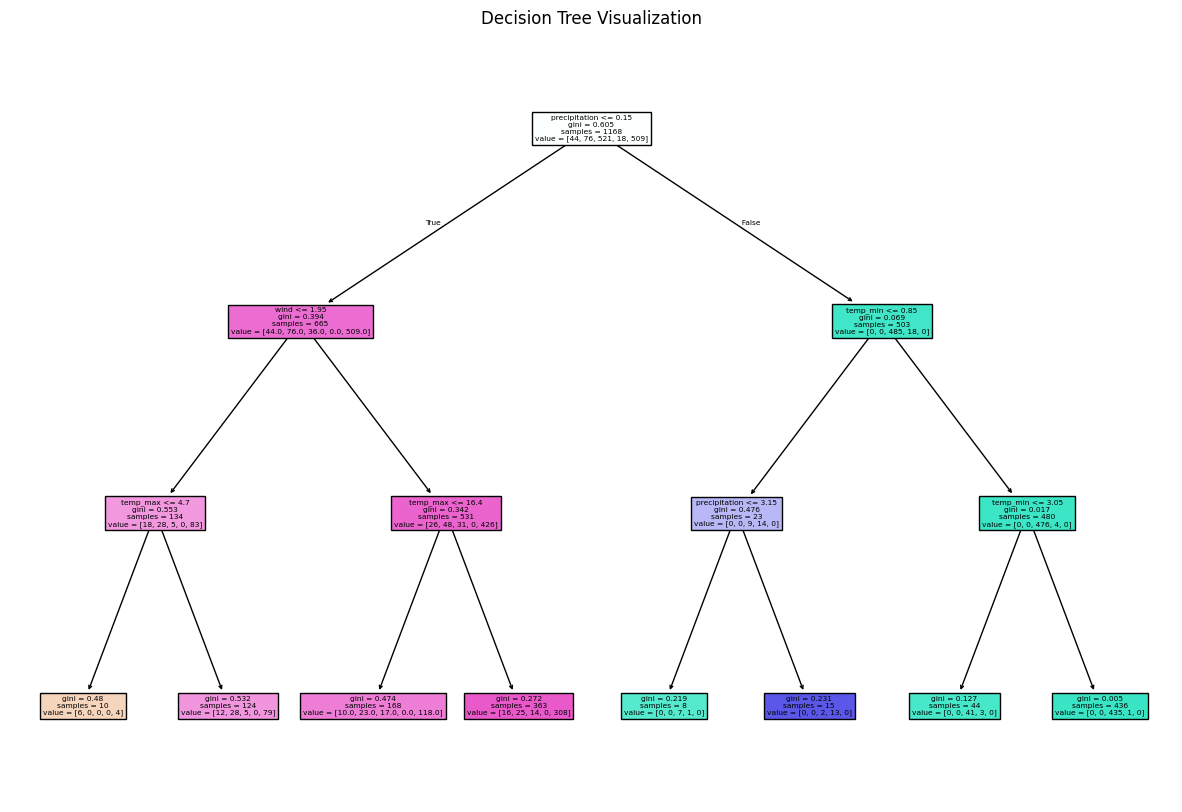

In [112]:
# plot the decision tree
plt.figure(figsize=(15,10))

plot_tree(
    d_model,
    feature_names=X.columns,
    #class_names=le.classes_, # this will show the original class names instead of numeric labels
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

## Steps 8: Model Evaluation

To evaluate the performance of the classification model, metrics such as the confusion matrix and accuracy score are applied. These metrics help assess the model’s overall accuracy, determine its fitness, and identify prediction errors as well as correctly classified instances for each class.

In [78]:
# model evaluation
print("Classification Report:")
print("--"*40)
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print("--"*40)
print(confusion_matrix(y_test, y_pred))
print("Accuracy Score:")
print("--"*40)
print(accuracy_score(y_test, y_pred))


Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     drizzle       0.50      0.11      0.18         9
         fog       0.00      0.00      0.00        25
        rain       0.95      0.92      0.93       120
        snow       0.50      0.25      0.33         8
         sun       0.77      1.00      0.87       131

    accuracy                           0.83       293
   macro avg       0.54      0.46      0.46       293
weighted avg       0.76      0.83      0.78       293

Confusion Matrix:
--------------------------------------------------------------------------------
[[  1   0   0   0   8]
 [  1   0   0   0  24]
 [  0   0 110   2   8]
 [  0   0   6   2   0]
 [  0   0   0   0 131]]
Accuracy Score:
--------------------------------------------------------------------------------
0.8327645051194539


c:\Users\Administrator\New folder\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\New folder\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Administrator\New folder\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

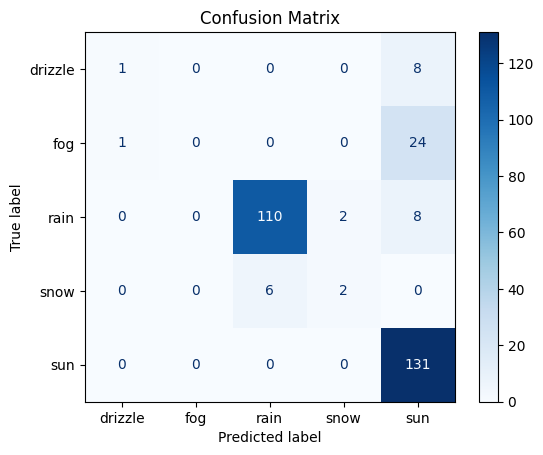

In [79]:
# plot confusion matrix
disp = ConfusionMatrixDisplay.from_estimator(d_model, X_test, y_test, cmap=plt.cm.Blues)
disp.ax_.set_title("Confusion Matrix")
plt.show()

### Summury for Decision Tree
The Decision Tree model achieved an accuracy of approximately 83% on training data and 80% on test data, using an 80/20 train-test split respectively. However, the model shows weaker performance in predicting the fog class.

Overall, the model performs well in classifying sunny and rainy conditions, with most samples being correctly identified for these two classes. But it struggles with less frequent or more complex weather conditions such as fog, drizzle, and snow, where the prediction accuracy is comparatively lower.

### Applyig Random forest model to improve perfomance
Now, we apply the Random Forest model to evaluate whether it can improve prediction performance compared to the Decision Tree model. Random Forest is an ensemble learning method that builds multiple decision trees and combines their results through majority voting, which helps reduce overfitting and improve generalization.

By using multiple trees instead of a single tree, the model becomes more robust and stable when handling complex relationships between features such as temperature, precipitation, wind, and month

In [54]:
# Random Forest Classifier
# Build the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rfy_pred = rf_model.predict(X_test)

In [68]:
# importance of features
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

importances = importances.sort_values('importance', ascending=False)

print(importances)

         feature  importance
0  precipitation    0.520974
1       temp_max    0.188808
2       temp_min    0.147810
3           wind    0.142409


In [55]:
# Model evaluation
print("Random Forest Classification Report:")
print("--"*40)
print(classification_report(y_test, rfy_pred))
print("Random Forest Confusion Matrix:")
print("--"*40)
print(confusion_matrix(y_test, rfy_pred))
print("Random Forest Accuracy Score:")
print(accuracy_score(y_test, rfy_pred))

Random Forest Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

     drizzle       0.20      0.11      0.14         9
         fog       0.40      0.08      0.13        25
        rain       0.92      0.91      0.92       120
        snow       0.33      0.25      0.29         8
         sun       0.78      0.95      0.86       131

    accuracy                           0.81       293
   macro avg       0.53      0.46      0.47       293
weighted avg       0.78      0.81      0.78       293

Random Forest Confusion Matrix:
--------------------------------------------------------------------------------
[[  1   0   0   0   8]
 [  1   2   2   0  20]
 [  0   0 109   4   7]
 [  0   0   6   2   0]
 [  3   3   1   0 124]]
Random Forest Accuracy Score:
0.8122866894197952


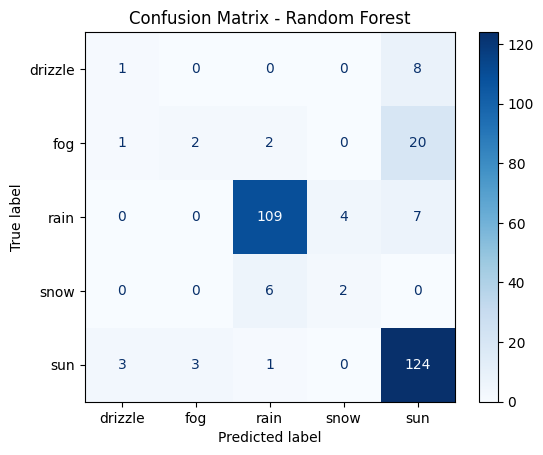

In [67]:
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model,
    X_test,
    y_test,
    cmap=plt.cm.Blues
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

### Summury for Random Forest 
The Random Forest model achieved an overall accuracy of 81%, which is slightly lower than the Decision Tree model. This may be due to the relatively small size of the dataset, which limits the model’s ability to learn strong and diverse patterns from the data.

### Try Xgboost Classifier

Next, we apply the XGBoost Classifier to improve the model performance. XGBoost is a powerful builds models  model that learns from the errors of the previous one. This helps in improving prediction accuracy and handling complex relationships within the dataset

In [56]:
# apply xgboost classifier
from xgboost import XGBClassifier
# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Initialize XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax', 
    num_class=len(le.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

c:\Users\Administrator\New folder\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [10:02:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [57]:
# model evaluation
print("XGBoost Classification Report:")
print("--"*40)
print(classification_report(y_test, xgb_pred))
print("XGBoost Confusion Matrix:")
print("--"*40)
print(confusion_matrix(y_test, xgb_pred))
print("XGBoost Accuracy Score:")
print(accuracy_score(y_test, xgb_pred))

XGBoost Classification Report:
--------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.50      0.11      0.18         9
           1       0.50      0.08      0.14        25
           2       0.94      0.91      0.92       120
           3       0.33      0.25      0.29         8
           4       0.77      0.97      0.86       131

    accuracy                           0.82       293
   macro avg       0.61      0.46      0.48       293
weighted avg       0.80      0.82      0.79       293

XGBoost Confusion Matrix:
--------------------------------------------------------------------------------
[[  1   0   0   0   8]
 [  0   2   0   0  23]
 [  0   0 109   4   7]
 [  0   0   6   2   0]
 [  1   2   1   0 127]]
XGBoost Accuracy Score:
0.8225255972696246


In [69]:
# feature importance for xgboost
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print(importance_df)

         Feature  Importance
0  precipitation    0.848126
1       temp_max    0.054600
2       temp_min    0.054400
3           wind    0.042873


### Summury for Xboosting
The XGBoost model achieved an overall accuracy of 82%, which is slightly lower than the Decision Tree model. This may be due to the small dataset size, which limits the model’s ability to fully learn complex patterns and relationships between features

## Step 9: Model Tuning and Prediction

After evaluating the model’s performance, the next step is to fine-tune the model to improve its accuracy and overall performance. This may involve adjusting model parameters or optimizing feature selection.

Once the model is optimized, it is then used to make predictions on new, unseen data in order to evaluate its real-world applicability and observe the predicted outputs.

In [110]:
# predicting weather for a new data point
# month input
d_model = joblib.load("Weather_prediction_model.pkl")
month_name = input("Month (e.g January): ").strip().lower()

month_map = {
    "january": 1, "february": 2, "march": 3,
    "april": 4, "may": 5, "june": 6,
    "july": 7, "august": 8, "september": 9,
    "october": 10, "november": 11, "december": 12
}

if month_name not in month_map:
    print("Invalid month name")
    exit()

month = month_map[month_name]

# other inputs features
precipitation = float(input("Precipitation: "))
temp_max = float(input("Temp Max: "))
temp_min = float(input("Temp Min: "))
wind = float(input("Wind: "))


# new data
new_data = pd.DataFrame([{
    "precipitation": precipitation,
    "temp_max": temp_max,
    "temp_min": temp_min,
    "wind": wind,
    "month": month
}])

# Prediction using the decision tree model
prediction = d_model.predict(new_data)

print(f"\nIn {month_name.title()}, predicted weather is: {prediction[0]}")


In June, predicted weather is: sun


## Steps 10: saving Model
After training and evaluating the machine learning model, we aregoing to save by applying libries techniques such as Pickle or Joblib. This allows the trained model to be reused later without retraining, making it efficient for deployment in real-world applications such as web-based prediction systems (flask).

In [109]:
# Save the model using joblib
model_filename = 'Weather_prediction_model.pkl'
joblib.dump(d_model, model_filename)

print(f"Model saved as '{model_filename}'")

Model saved as 'Weather_prediction_model.pkl'
